In [18]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import uncertainties.unumpy as unp


from acspype import ACSTSCor


In [38]:
tscor = ACSTSCor().to_xarray()  ## Load the TSCor coefficients as an xarray dataset.

psi_t = tscor.psi_t.sel(wavelength=715).values
psi_s = tscor.psi_s_a.sel(wavelength=715).values

In [39]:
temperature = unp.uarray(15,np.arange(0.00, 1.005, 0.005))
salinity = unp.uarray(32,np.arange(0.00, 1.505, 0.005))
t, s = np.meshgrid(temperature, salinity)

In [40]:
mts = 1.5 - ((psi_t * t) + (psi_s * s))

In [41]:
uz = unp.std_devs(mts)

In [45]:
uz

array([[0.00000000e+00, 2.08000000e-05, 4.16000000e-05, ...,
        4.11840000e-03, 4.13920000e-03, 4.16000000e-03],
       [1.03000000e-06, 2.08254868e-05, 4.16127492e-05, ...,
        4.11840013e-03, 4.13920013e-03, 4.16000013e-03],
       [2.06000000e-06, 2.09017607e-05, 4.16509736e-05, ...,
        4.11840052e-03, 4.13920051e-03, 4.16000051e-03],
       ...,
       [3.06940000e-04, 3.07643956e-04, 3.09746225e-04, ...,
        4.12982212e-03, 4.15056488e-03, 4.17130821e-03],
       [3.07970000e-04, 3.08671607e-04, 3.10766924e-04, ...,
        4.12989880e-03, 4.15064117e-03, 4.17138413e-03],
       [3.09000000e-04, 3.09699273e-04, 3.11787684e-04, ...,
        4.12997573e-03, 4.15071773e-03, 4.17146030e-03]], shape=(301, 201))

In [42]:
uy = unp.std_devs(t)

In [43]:
ux = unp.std_devs(s)

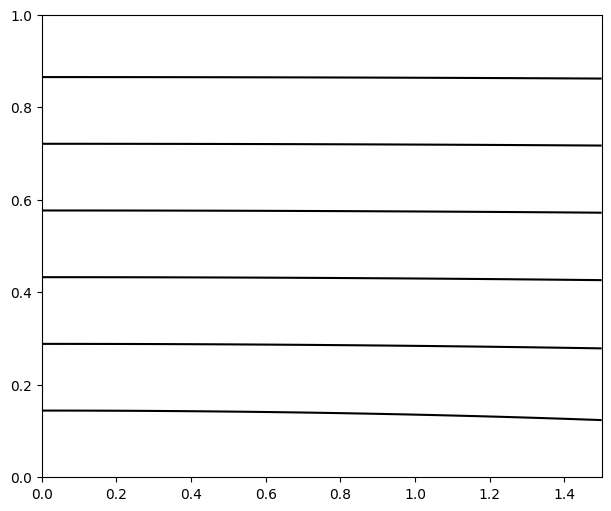

In [44]:
fig, ax = plt.subplots(1,1, figsize = (6,5), constrained_layout = True, sharex = True, sharey = True)

#pcon0 = ax.contour()

pcon0 = ax.contour(ux,uy,uz, colors = 'k')
#ax[0,0].clabel(pcon0, pcon0.levels,fmt = r"$\pm$%0.4f $m^{-1}$",fontsize = 10)


In [ ]:

temp = unp.uarray(15,np.arange(0.00,.75,0.05))
sal = unp.uarray(32,np.arange(0.00,.75,0.05))

dev_fp = '../acspype/dev_tools/test_files/ACS-00412_2023-05-10.dev'
dev = ACSDev(dev_fp)
tcal = dev.tcal

tscor = ACSTSCor().to_xarray()  ## Load the TSCor coefficients as an xarray dataset.


In [ ]:
c_m = 1.5

psi_t_c = tscor.psi_t.sel(wavelength=660).values
psi_s_c = tscor.psi_s_c.sel(wavelength=660).values

sigma_t = tscor.sigma_psi_t.sel(wavelength = 660).values
sigma_s = tscor.sigma_psi_s_c.sel(wavelength = 660).values
psi_t_c = unp.uarray(psi_t_c, sigma_t)
psi_s_c = unp.uarray(psi_s_c, sigma_s)

tc, psi_tc = np.meshgrid(temp, psi_t_c)
sc, psi_sc = np.meshgrid(sal, psi_s_c)
ux = unp.std_devs(tc)
uy = unp.std_devs(sc)

tc, sc = np.meshgrid(tc, sc)
psi_sc, psi_tc = np.meshgrid(psi_sc, psi_tc)

mts = c_m - ((psi_tc * tc.T) + (psi_sc * sc.T))

cUX, cUY = np.meshgrid(ux,uy)
cUZ = unp.std_devs(mts)

In [ ]:
c_m = 1.5

psi_t_c = tscor.psi_t.sel(wavelength=715).values
psi_s_c = tscor.psi_s_c.sel(wavelength=715).values

sigma_t = tscor.sigma_psi_t.sel(wavelength = 715).values
sigma_s = tscor.sigma_psi_s_c.sel(wavelength = 715).values
psi_t_c = unp.uarray(psi_t_c, sigma_t)
psi_s_c = unp.uarray(psi_s_c, sigma_s)

tc, psi_tc = np.meshgrid(temp, psi_t_c)
sc, psi_sc = np.meshgrid(sal, psi_s_c)
ux = unp.std_devs(tc)
uy = unp.std_devs(sc)

tc, sc = np.meshgrid(tc, sc)
psi_sc, psi_tc = np.meshgrid(psi_sc, psi_tc)

mts = c_m - ((psi_tc * tc.T) + (psi_sc * sc.T))


cUX2, cUY2 = np.meshgrid(ux,uy)
cUZ2 = unp.std_devs(mts)

In [ ]:
a_m = 1.5

psi_t_a = tscor.psi_t.sel(wavelength=676).values
psi_s_a = tscor.psi_s_a.sel(wavelength=676).values

sigma_t = tscor.sigma_psi_t.sel(wavelength = 676).values
sigma_s = tscor.sigma_psi_s_a.sel(wavelength = 676).values
psi_t_a = unp.uarray(psi_t_a, sigma_t)
psi_s_a = unp.uarray(psi_s_a, sigma_s)


ta, psi_ta = np.meshgrid(temp, psi_t_a)
sa, psi_sa = np.meshgrid(sal, psi_s_a)
ux = unp.std_devs(ta)
uy = unp.std_devs(sa)

ta, sa = np.meshgrid(ta, sa)
psi_sa, psi_ta = np.meshgrid(psi_sa, psi_ta)


mts = a_m - ((psi_ta * ta.T) + (psi_sa * sa.T))


aUX, aUY = np.meshgrid(ux,uy)
aUZ = unp.std_devs(mts)

In [ ]:
a_m = 1.5

psi_t_a = tscor.psi_t.sel(wavelength=715).values
psi_s_a = tscor.psi_s_a.sel(wavelength=715).values

sigma_t = tscor.sigma_psi_t.sel(wavelength = 715).values
sigma_s = tscor.sigma_psi_s_a.sel(wavelength = 715).values
psi_t_a = unp.uarray(psi_t_a, sigma_t)
psi_s_a = unp.uarray(psi_s_a, sigma_s)

ta, psi_ta = np.meshgrid(temp, psi_t_a)
sa, psi_sa = np.meshgrid(sal, psi_s_a)
ux = unp.std_devs(ta)
uy = unp.std_devs(sa)

ta, sa = np.meshgrid(ta, sa)
psi_sa, psi_ta = np.meshgrid(psi_sa, psi_ta)

mts = a_m - ((psi_ta * ta.T) + (psi_sa * sa.T))


aUX2, aUY2 = np.meshgrid(ux,uy)
aUZ2 = unp.std_devs(mts)

In [ ]:
fig, ax = plt.subplots(2,2, figsize = (6,5), constrained_layout = True, sharex = True, sharey = True)


pcon0 = ax[0,0].contour(aUX, aUY, aUZ, levels = [0.00152,0.0015338,0.00154,], colors = 'k')
ax[0,0].clabel(pcon0, pcon0.levels,fmt = r"$\pm$%0.4f $m^{-1}$",fontsize = 10)

pcon1 = ax[0,1].contour(aUX2, aUY2, aUZ2, levels = [0.0074,0.0075,0.0076,0.0077,0.0078,0.0079], colors = 'k')
ax[0,1].clabel(pcon1, pcon1.levels,fmt = r"$\pm$%0.4f $m^{-1}$",fontsize = 10)


pcon2 = ax[1,0].contour(cUX, cUY, cUZ, levels = [0.003534,0.003535],colors = 'k')
ax[1,0].clabel(pcon2, pcon2.levels, fmt = r"$\pm$%0.4f $m^{-1}$",fontsize = 10)

#pcon3 = ax[1,1].contour(cUX2, cUY2, cUZ2, levels = [1e-6,1e-5,1e-4,1e-3], colors = 'k')
pcon3 = ax[1,1].contour(cUX2, cUY2, cUZ2, levels = [0.0081,0.0082,0.0083,0.0084,0.0085,0.0086], colors = 'k')
#ax[1,1].clabel(pcon3, pcon3.levels, fmt = r"$\pm$%1.e $m^{-1}$",fontsize = 10)
ax[1,1].clabel(pcon3, pcon3.levels, fmt = r"$\pm$%0.4f $m^{-1}$",fontsize = 10)

ax[0,0].set_ylabel(r'$U_{T}$ $(^{\circ}C)$')
ax[1,0].set_ylabel(r'$U_{T}$ $(^{\circ}C)$')
ax[1,0].set_xlabel(r'$U_{S}$ $(PSU)$')
ax[1,1].set_xlabel(r'$U_{S}$ $(PSU)$')

ax[0,0].set_title(r'$a_{676}$')
ax[0,1].set_title(r'$a_{715}$')
ax[1,0].set_title(r'$c_{660}$')
ax[1,1].set_title(r'$c_{715}$')

ax[-1,-1].xaxis.set_major_locator(MultipleLocator(0.2))
ax[-1,-1].yaxis.set_major_locator(MultipleLocator(0.2))
ax[-1,-1].xaxis.set_minor_locator(MultipleLocator(0.1))
ax[-1,-1].yaxis.set_minor_locator(MultipleLocator(0.1))

plt.savefig('uncertainty_ts_corr_w_sullivan.jpg',dpi = 600)

In [ ]:
c_m = 1.5

psi_t_c = tscor.psi_t.sel(wavelength=660).values
psi_s_c = tscor.psi_s_c.sel(wavelength=660).values


tc, psi_tc = np.meshgrid(temp, psi_t_c)
sc, psi_sc = np.meshgrid(sal, psi_s_c)
ux = unp.std_devs(tc)
uy = unp.std_devs(sc)

tc, sc = np.meshgrid(tc, sc)
psi_sc, psi_tc = np.meshgrid(psi_sc, psi_tc)

mts = c_m - ((psi_tc * tc.T) + (psi_sc * sc.T))
#mts = c_m - ((psi_tc * tc) + (psi_sc * sc))

cUX, cUY = np.meshgrid(ux,uy)
cUZ = unp.std_devs(mts)


c_m = 1.5

psi_t_c = tscor.psi_t.sel(wavelength=715).values
psi_s_c = tscor.psi_s_c.sel(wavelength=715).values


tc, psi_tc = np.meshgrid(temp, psi_t_c)
sc, psi_sc = np.meshgrid(sal, psi_s_c)
ux = unp.std_devs(tc)
uy = unp.std_devs(sc)

tc, sc = np.meshgrid(tc, sc)
psi_sc, psi_tc = np.meshgrid(psi_sc, psi_tc)

mts = c_m - ((psi_tc * tc.T) + (psi_sc * sc.T))
#mts = c_m - ((psi_tc * tc) + (psi_sc * sc))


cUX2, cUY2 = np.meshgrid(ux,uy)
cUZ2 = unp.std_devs(mts)


a_m = 1.5

psi_t_a = tscor.psi_t.sel(wavelength=676).values
psi_s_a = tscor.psi_s_a.sel(wavelength=676).values

ta, psi_ta = np.meshgrid(temp, psi_t_a)
sa, psi_sa = np.meshgrid(sal, psi_s_a)
ux = unp.std_devs(ta)
uy = unp.std_devs(sa)

ta, sa = np.meshgrid(ta, sa)
psi_sa, psi_ta = np.meshgrid(psi_sa, psi_ta)


mts = a_m - ((psi_ta * ta.T) + (psi_sa * sa.T))
#mts = a_m - ((psi_ta * ta) + (psi_sa * sa))


aUX, aUY = np.meshgrid(ux,uy)
aUZ = unp.std_devs(mts)



a_m = 1.5

psi_t_a = tscor.psi_t.sel(wavelength=715).values
psi_s_a = tscor.psi_s_a.sel(wavelength=715).values

ta, psi_ta = np.meshgrid(temp, psi_t_a)
sa, psi_sa = np.meshgrid(sal, psi_s_a)
ux = unp.std_devs(ta)
uy = unp.std_devs(sa)

ta, sa = np.meshgrid(ta, sa)
psi_sa, psi_ta = np.meshgrid(psi_sa, psi_ta)

mts = a_m - ((psi_ta * ta.T) + (psi_sa * sa.T))
#mts = a_m - ((psi_ta * ta) + (psi_sa * sa))

aUX2, aUY2 = np.meshgrid(ux,uy)
aUZ2 = unp.std_devs(mts)

In [ ]:
# psi_t_c = tscor.psi_t.sel(wavelength=660).values
# psi_s_c = tscor.psi_s_c.sel(wavelength=660).values
#
# tc = temp
# sc = sal
# uy = unp.std_devs(tc)
# ux = unp.std_devs(sc)
# t, s = np.meshgrid(tc,sc)
# mts = c_m - ((psi_t_c * t) + (psi_s_c*s))
#
# cUX, cUY = np.meshgrid(ux,uy)
# cUZ = unp.std_devs(mts)
#
#
#
# psi_t_c = tscor.psi_t.sel(wavelength=715).values
# psi_s_c = tscor.psi_s_c.sel(wavelength=715).values
#
# tc = temp
# sc = sal
# uy = unp.std_devs(tc)
# ux = unp.std_devs(sc)
# t, s = np.meshgrid(tc,sc)
# mts = c_m - ((psi_t_c * t) + (psi_s_c*s))
#
# cUX2, cUY2 = np.meshgrid(ux,uy)
# cUZ2 = unp.std_devs(mts)
#
#
# psi_t_a = tscor.psi_t.sel(wavelength=676).values
# psi_s_a = tscor.psi_s_a.sel(wavelength=676).values
#
# ta = temp
# sa = sal
# uy = unp.std_devs(ta)
# ux = unp.std_devs(sa)
# t, s = np.meshgrid(ta,sa)
# mts = a_m - ((psi_t_a * t) + (psi_s_a*s))
#
# aUX, aUY = np.meshgrid(ux,uy)
# aUZ = unp.std_devs(mts)
#
#
#
# psi_t_a = tscor.psi_t.sel(wavelength=715).values
# psi_s_a = tscor.psi_s_a.sel(wavelength=715).values
#
# ta = temp
# sa = sal
# uy = unp.std_devs(ta)
# ux = unp.std_devs(sa)
# t, s = np.meshgrid(ta,sa)
# mts = a_m - ((psi_t_a * t.T) + (psi_s_a*s))
#
# aUX2, aUY2 = np.meshgrid(ux,uy)
# aUZ2 = unp.std_devs(mts)


In [ ]:
fig, ax = plt.subplots(2,2, figsize = (6,5), constrained_layout = True, sharex = True, sharey = True)


pcon0 = ax[0,0].contour(aUX, aUY, aUZ,levels = [0.00001,0.00002,0.00003], colors = 'k')
ax[0,0].clabel(pcon0, pcon0.levels,fmt = r"$\pm$%0.5f $m^{-1}$",fontsize = 10)

pcon1 = ax[0,1].contour(aUX2, aUY2, aUZ2, levels = [0.0005,0.001,0.002,],colors = 'k')
ax[0,1].clabel(pcon1, pcon1.levels,fmt = r"$\pm$%0.5f $m^{-1}$",fontsize = 10)


pcon2 = ax[1,0].contour(cUX, cUY, cUZ,levels = [0.00001,0.00005,0.0001],colors = 'k')
ax[1,0].clabel(pcon2, pcon2.levels, fmt = r"$\pm$%0.5f $m^{-1}$",fontsize = 10)

pcon3 = ax[1,1].contour(cUX2, cUY2, cUZ2,levels = [0.0005,0.001,0.002], colors = 'k')
ax[1,1].clabel(pcon3, pcon3.levels, fmt = r"$\pm$%0.5f $m^{-1}$",fontsize = 10)

ax[0,0].set_ylabel(r'$U_{T}$ $(^{\circ}C)$')
ax[1,0].set_ylabel(r'$U_{T}$ $(^{\circ}C)$')
ax[1,0].set_xlabel(r'$U_{S}$ $(PSU)$')
ax[1,1].set_xlabel(r'$U_{S}$ $(PSU)$')

ax[0,0].set_title(r'$a_{676}$')
ax[0,1].set_title(r'$a_{715}$')
ax[1,0].set_title(r'$c_{660}$')
ax[1,1].set_title(r'$c_{715}$')

ax[-1,-1].xaxis.set_major_locator(MultipleLocator(0.2))
ax[-1,-1].yaxis.set_major_locator(MultipleLocator(0.2))
ax[-1,-1].xaxis.set_minor_locator(MultipleLocator(0.1))
ax[-1,-1].yaxis.set_minor_locator(MultipleLocator(0.1))

plt.savefig('uncertainty_ts_corr.jpg',dpi = 600)